### 비모수 검정
- t검정, ANOVA 안맞는 상황에 사용
- 데이터가 치우쳐져 있을 때
- 순위를 이용하는 비모수 검정 3가지
-> 비모수는 대표 지표로 평균이 아니라 중앙값 사용한다! 치우쳐져 있으니. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/07-8_seoul_market_sales.csv")
df.head(3)

,기준_년분기_코드,상권_구분_코드_명,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,남성_매출_금액,여성_매출_금액,연령대_10_매출_금액,연령대_20_매출_금액,연령대_30_매출_금액,연령대_40_매출_금액,연령대_50_매출_금액,연령대_60_이상_매출_금액
0,20254,발달상권,"신촌역(신촌역, 신촌로터리)",스포츠 강습,190574012,563,185879107,4694905,62004846,122818273,1578072,62149177,70583498,12783010,35309971,2419391
1,20254,전통시장,동화동 골목형상점가,미용실,241121913,7596,158201210,82920703,110263603,126565631,689103,17374758,40986830,66989251,63290864,47498428
2,20254,전통시장,노량진중앙시장,커피-음료,143339677,43869,95844027,47495650,84490667,57487331,2121862,42653948,43692418,15772423,24945022,12792323


In [9]:
df[df['당월_매출_금액'] >= 148993825259]

,기준_년분기_코드,상권_구분_코드_명,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,남성_매출_금액,여성_매출_금액,연령대_10_매출_금액,연령대_20_매출_금액,연령대_30_매출_금액,연령대_40_매출_금액,연령대_50_매출_금액,연령대_60_이상_매출_금액
638,20254,발달상권,노량진역(노량진),수산물판매,1148993825259,13299388,702979967421,446013857838,593622758684,368756136564,1118585864,101894366341,205599236387,163868180468,191816788897,298081737292
1427,20254,전통시장,청량리청과물시장,청과상,183825968781,10094334,125103167602,58722801179,86175014201,86129400597,182848362,3832634964,13396292927,25995176019,49385879073,79511583452
3064,20254,발달상권,가산디지털단지,일반의류,529180460200,6183330,279036871818,250143588382,241974717221,287138518257,820590155,32421392359,102707763131,131573914557,147645672800,113943902478
3737,20254,발달상권,잠실역,일반의류,184115613592,4796538,110568944893,73546668699,62658985480,121455407773,1324628846,31171572215,58891101979,45669695662,28079956165,18977438386


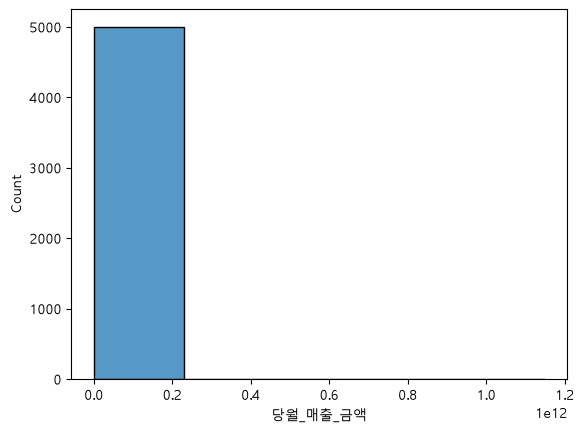

In [6]:
# 시각화해서 데이터 분포도 보기

sns.histplot(df['당월_매출_금액'], bins=5)
plt.show()

#### 1. Mann-Whitney U
- 관광 특구와 골목 상권의 매출이 다를까?
- 서로 다른 두 그룹의 독립 검정 -> 데이터가 치우쳐져 있으니 -> 비모수검정

In [12]:
# 골목상권의 당월 매출
street = df[df['상권_구분_코드_명'] == "골목상권"]['당월_매출_금액']
tourism = df[df['상권_구분_코드_명'] == "관광특구"]['당월_매출_금액']

In [13]:
print("관광특구 중앙값", tourism.median())
print("골목상권 중앙값", street.median())

관광특구 중앙값 1039448928.5
골목상권 중앙값 101829029.5


In [17]:
u, p = stats.mannwhitneyu(tourism, street)

print("p-value:", p) #p값 매우 작으므로 두 상권 매출 유의미하게 다름
print("u:", u)

p-value: 5.0905616004348616e-11
u: 92865.0


#### 2. Wilcoxon
- 대응하는 두 조건을 검증(대응 t검정 대안)
- 같은 상권의 주중 매출과 주말 매출이 다를까?
- 같은 상권이니까 -> 대응 t검정 해야 하는데 -> 데이터 치우쳐져 있으니 -> 비모수 사용

In [18]:
w, p = stats.wilcoxon(df['주중_매출_금액'], df['주말_매출_금액'])
print("p-value:", p)

p-value: 0.0


#### 3. Kruskal-Wallis - 세그룹 이상(ANOVA 대안)

In [20]:
groups = []

for name, group in df.groupby("상권_구분_코드_명"):
    # print(name, group)
    groups.append(group['당월_매출_금액'].values)

h, p = stats.kruskal(*groups)

print("h 통계량:", h)
print("p-value:", p)

h 통계량: 454.1409256281272
p-value: 4.1308510809539815e-98
